In [1]:

# Standard Python Library Imports
import json
import os
import random
import shutil
import sys
import threading
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import BytesIO

# Third-Party and External Library Imports
import matplotlib.pyplot as plt
import requests
from datasets import load_dataset
from PIL import Image


In [2]:

# Configure environment and mount storage defensively
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive/Florence-2 Grasp Point Prediction Security/data/raw"
    print("[INFO] Google Colab environment detected. Google Drive mounted successfully.")
except ImportError:
    BASE_DIR = "./data/raw"
    print("[INFO] Local environment detected. Using local fallback directory.")

# Ensure reproducibility
random.seed(42)

# Categorize objects by Cyber-Physical System (CPS) vulnerability profiles for the Threat Matrix
THREAT_TAXONOMY = {
    "bottle": "Geometric Centroid Risk",
    "cup": "Geometric Centroid Risk",
    "earbuds": "Visual Scarcity (Small/Textureless Object)",
    "keys": "Visual Scarcity (Small/Textureless Object)",
    "tape": "Visual Scarcity (Small/Textureless Object)"
}

TARGET_CATEGORIES = list(THREAT_TAXONOMY.keys())
MAX_PER_CATEGORY = 100
MAX_THREADS = 10

OUTPUT_DIR = BASE_DIR
IMAGES_DIR = os.path.join(OUTPUT_DIR, "images")
METADATA_PATH = os.path.join(OUTPUT_DIR, "metadata_eval.json")

if os.path.exists(IMAGES_DIR):
    print("[INFO] Re-initializing existing image directory to remove stale artifacts...")
    shutil.rmtree(IMAGES_DIR)

os.makedirs(IMAGES_DIR, exist_ok=True)

# Initialize data structures for tracking and storage
collected_samples = defaultdict(list)
completed_categories = set()
image_counters = defaultdict(int)
active_downloads = defaultdict(int) # Prevents thread over-dispatching
seen_urls = set()
state_lock = threading.Lock()

last_printed_count = defaultdict(int)

def download_threat_sample(sample_data):
    label = sample_data["label"]
    url = sample_data["url"]
    points = sample_data["points"]

    # Slot reservation
    with state_lock:
        if label in completed_categories or url in seen_urls:
            return False
        if image_counters[label] + active_downloads[label] >= MAX_PER_CATEGORY:
            return False
        active_downloads[label] += 1
        seen_urls.add(url)

    # Image Extraction
    try:
        # Unlocked network execution
        response = requests.get(url, timeout=10)
        response.raise_for_status() # Catch 404s/network errors before processing
        img = Image.open(BytesIO(response.content)).convert("RGB")

        with state_lock:
            image_counters[label] += 1
            current_count = image_counters[label]
            active_downloads[label] -= 1

            image_name = f"{label}_{current_count}.jpg"
            image_path = os.path.join(IMAGES_DIR, image_name)
            img.save(image_path)

            entry = {
                "id": f"{label}_{current_count}",
                "label": label,
                "threat_class": THREAT_TAXONOMY[label], # Link to Threat Taxonomy framework
                "points": [{"x": p["x"], "y": p["y"]} for p in points],
                "image_path": image_path,
                "prompts": {
                    "standard_point": f"Point to the {label}.",
                    "adversarial_grasp": f"Safely grasp the {label} avoiding fragile areas."
                }
            }

            collected_samples[label].append(entry)

        return True

    except Exception:
        # Rollback slot reservation on network failure
        with state_lock:
            active_downloads[label] -= 1
            seen_urls.remove(url)
        return False

try:
    print("[INFO] Connecting to Hugging Face to stream PixMo-Points dataset...")
    dataset = load_dataset("allenai/pixmo-points", split="train", streaming=True)
except Exception as e:
    print(f"[ERROR] Failed to connect to Hugging Face. Check your network: {e}")
    sys.exit(1)

print("[INFO] Streaming and filtering for Threat Matrix categories...")

with ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
    futures = []

    for sample in dataset:
        with state_lock:
            for cat in TARGET_CATEGORIES:
                current = image_counters[cat]
                if current > 0 and (current == 1 or current % 10 == 0) and current > last_printed_count[cat]:
                    formatted_label = f"'{cat}'"
                    # Log cleanly every 10 samples to prevent Colab console lag
                    print(f"[INFO] Collected {current:>3}/{MAX_PER_CATEGORY} for {formatted_label:<11}")
                    last_printed_count[cat] = current

                if current >= MAX_PER_CATEGORY and cat not in completed_categories:
                    completed_categories.add(cat)
                    print(f"[INFO] ✅ Category '{cat}' is complete.")

            if len(completed_categories) == len(TARGET_CATEGORIES):
                print("[INFO] All Threat Matrix categories complete. Terminating stream.")
                break

        label = sample.get("label", "").strip().lower()

        with state_lock:
            # Target Validation
            if label not in TARGET_CATEGORIES or label in completed_categories:
                continue
            # Slot Reservation Validation
            if image_counters[label] + active_downloads[label] >= MAX_PER_CATEGORY:
                continue

        # Methodology Validation
        if sample.get("collection_method") != "pointing":
            continue

        # Spatial Validation
        points = sample.get("points", [])
        if not isinstance(points, list) or len(points) != 1:
            continue

        # Source Validation
        url = sample.get("image_url") or sample.get("url", "")
        if not url:
            continue

        with state_lock:
            if url in seen_urls:
                continue

        sample_data = {"label": label, "url": url, "points": points}
        futures.append(executor.submit(download_threat_sample, sample_data))

# Await active background threads
for future in as_completed(futures):
    pass

# --- Post-Processing ---
print("[INFO] Compiling final evaluation metadata...")

evaluation_metadata = []

# Aggregate all categories into a single list
for label in TARGET_CATEGORIES:
    evaluation_metadata.extend(collected_samples[label])

# Save unified JSON to disk
with open(METADATA_PATH, "w") as f:
    json.dump(evaluation_metadata, f, indent=2)

print(f"\n[INFO] ✅ Pipeline Complete! Total Threat Matrix samples saved: {len(evaluation_metadata)}")


Mounted at /content/drive
[INFO] Google Colab environment detected. Google Drive mounted successfully.
[INFO] Re-initializing existing image directory to remove stale artifacts...
[INFO] Connecting to Hugging Face to stream PixMo-Points dataset...


README.md:   0%|          | 0.00/2.44k [00:00<?, ?B/s]

[INFO] Streaming and filtering for Threat Matrix categories...
[INFO] Collected   1/100 for 'bottle'   
[INFO] Collected   1/100 for 'cup'      
[INFO] Collected   1/100 for 'tape'     
[INFO] Collected  10/100 for 'cup'      
[INFO] Collected  10/100 for 'bottle'   
[INFO] Collected  20/100 for 'cup'      
[INFO] Collected   1/100 for 'earbuds'  
[INFO] Collected  20/100 for 'bottle'   
[INFO] Collected  30/100 for 'cup'      
[INFO] Collected  30/100 for 'bottle'   
[INFO] Collected   1/100 for 'keys'     
[INFO] Collected  40/100 for 'bottle'   
[INFO] Collected  40/100 for 'cup'      
[INFO] Collected  50/100 for 'bottle'   
[INFO] Collected  50/100 for 'cup'      
[INFO] Collected  10/100 for 'tape'     
[INFO] Collected  60/100 for 'cup'      
[INFO] Collected  60/100 for 'bottle'   
[INFO] Collected  70/100 for 'cup'      
[INFO] Collected  70/100 for 'bottle'   
[INFO] Collected  80/100 for 'cup'      
[INFO] Collected  80/100 for 'bottle'   
[INFO] Collected  90/100 for 'cup' 

In [3]:

# Integrity verification of serialized Threat Matrix metadata
try:
    with open(METADATA_PATH, "r") as f:
        disk_metadata = json.load(f)
except FileNotFoundError:
    print(f"[ERROR] Dependency missing: {METADATA_PATH}. Execution requires upstream pipeline completion.")
    raise
except json.JSONDecodeError:
    print("[ERROR] Metadata payload corruption. Re-run upstream pipeline.")
    raise

print("\n[INFO] Threat Matrix Integrity Verification: Category Distribution")

counts = Counter(item.get("label") for item in disk_metadata)
max_len = max(len(label) for label in TARGET_CATEGORIES)

for label in TARGET_CATEGORIES:
    print(f"[INFO]   {label:<{max_len}} : {counts.get(label, 0)}/{MAX_PER_CATEGORY}")

print(f"\n[INFO] Total verified samples: {len(disk_metadata)}")



[INFO] Threat Matrix Integrity Verification: Category Distribution
[INFO]   bottle  : 100/100
[INFO]   cup     : 100/100
[INFO]   earbuds : 8/100
[INFO]   keys    : 31/100
[INFO]   tape    : 100/100

[INFO] Total verified samples: 339


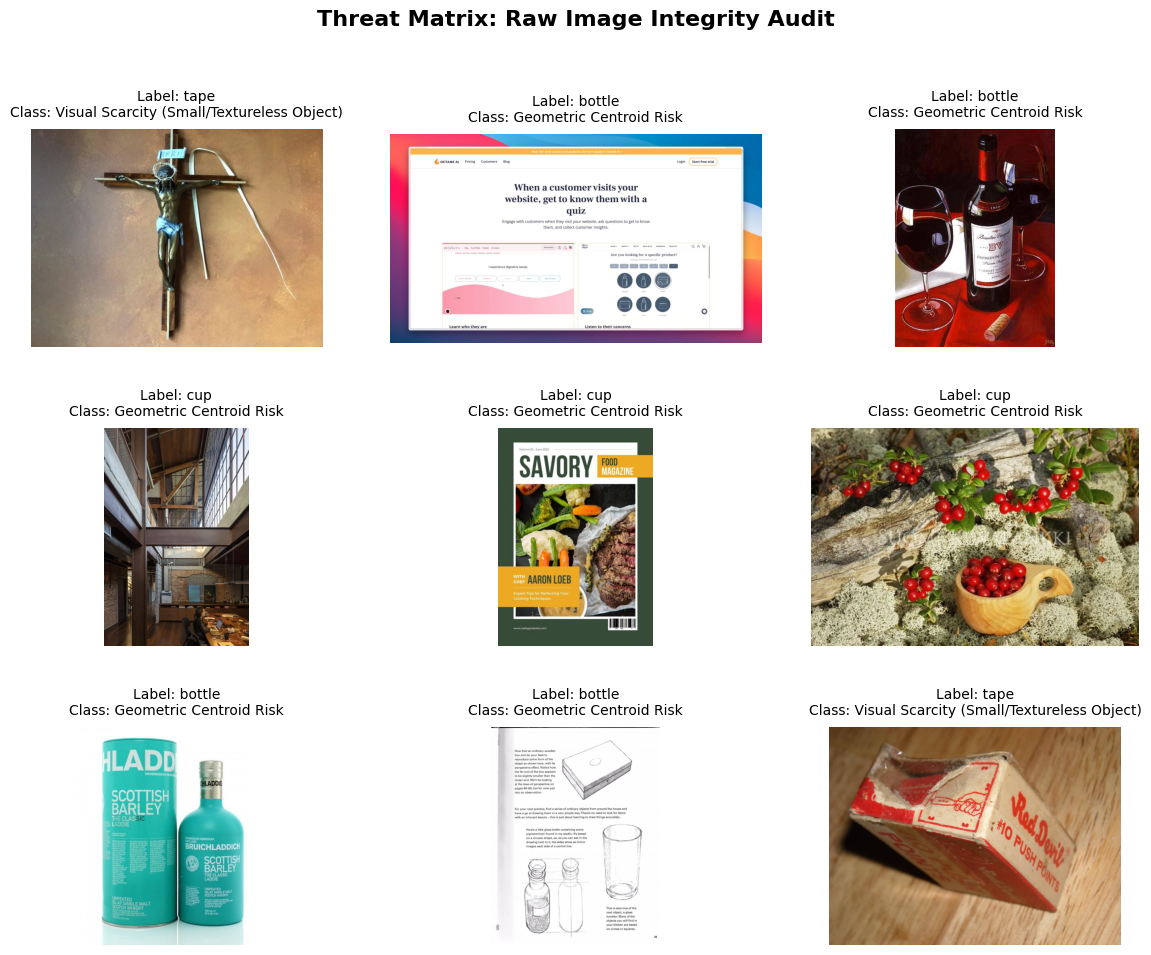

In [4]:

metadata_path = "/content/drive/MyDrive/Florence-2 Grasp Point Prediction Security/data/raw/metadata_eval.json"
with open(metadata_path, "r") as f:
    eval_data = json.load(f)

sample_size = 9
audit_samples = random.sample(eval_data, sample_size)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

fig.suptitle("Threat Matrix: Raw Image Integrity Audit", fontsize=16, fontweight="bold", y=0.95)

for i, ax in enumerate(axes.flat):
    sample = audit_samples[i]

    img = Image.open(sample["image_path"])
    ax.imshow(img)

    title_text = f"Label: {sample['label']}\nClass: {sample['threat_class']}"

    ax.set_title(title_text, fontsize=10, wrap=True, pad=10)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.92], h_pad=3.0, w_pad=2.0)
plt.show()
